In [2259]:
import numpy as np

In [2260]:
def erreur(x, w, y):
  y_model = model(x, w)
  distance = (y - y_model) **2
  return np.sum(distance)

In [2261]:
def erreur(X, Y, W, B):

  M = np.dot(X, W)

  P = M + B

  L = np.mean((Y-P) ** 2)

  return L # (Loss)

In [2262]:
X = np.array([
    [2, 3, -2],
    [4, 5, -1],
    [-5, 2, 3],
    [0, 5, 4]
])

In [2263]:
X.shape

(4, 3)

In [2264]:
Y = np.array([
    [2],
    [5],
    [6],
    [3]
])

In [2265]:
Y.shape

(4, 1)

In [2266]:
W = np.array([
    [0.02],
    [18],
    [15]
])

In [2267]:
W.shape

(3, 1)

In [2268]:
B = 0.5

In [2269]:
erreur(X, Y, W, B)

np.float64(8232.7495)

In [2270]:
params = {"W": W, "B": B}

In [2271]:
params

{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [2272]:
params['W']

array([[ 0.02],
       [18.  ],
       [15.  ]])

In [2273]:
params['B']

0.5

In [2274]:
def erreur(X, Y, params):

  info = {}

  M = np.dot(X, params['W'])

  P = M + params['B']

  L = np.mean((Y-P) ** 2)

  info['M'] = M
  info['P'] = P

  info['X'] = X
  info['Y'] = Y



  return L, info

In [2275]:
loss, info = erreur(X, Y, params)

In [2276]:
loss

np.float64(8232.7495)

In [2277]:
info

{'M': array([[ 24.04],
        [ 75.08],
        [ 80.9 ],
        [150.  ]]),
 'P': array([[ 24.54],
        [ 75.58],
        [ 81.4 ],
        [150.5 ]]),
 'X': array([[ 2,  3, -2],
        [ 4,  5, -1],
        [-5,  2,  3],
        [ 0,  5,  4]]),
 'Y': array([[2],
        [5],
        [6],
        [3]])}

In [2278]:
W.shape

(3, 1)

In [2279]:
W

array([[ 0.02],
       [18.  ],
       [15.  ]])

In [2280]:
B

0.5

In [2281]:
def gradient(info, params):
  grads = {}

  dL_dP = -2 * (info['Y'] - info['P']) # (4, 1)

  dP_dM = 1

  dM_dW = info['X'].T #(3, 4)


  dL_dW = np.dot(dM_dW, dL_dP) * dP_dM   # (4, 1) * (3, 4)  → (3, 4) (4, 1)
  grads['W'] = dL_dW

  # print (f'{dL_dP = }', f'{dP_dM = }', f'{dM_dW = }', sep='\n')

  dP_dB = 1

  dL_dB = dL_dP * dP_dB #(4, 1) * 1

  dL_dB = np.sum(dL_dB)

  grads['B'] = dL_dB

  return grads

In [2282]:
grads = gradient(info, params)
grads

{'W': array([[ -99.2 ],
        [2617.64],
        [1401.08]]),
 'B': np.float64(632.04)}

In [2283]:
B

0.5

In [2284]:
params

{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [2285]:
grads

{'W': array([[ -99.2 ],
        [2617.64],
        [1401.08]]),
 'B': np.float64(632.04)}

# Descente du gradient (Gradient descent) → 0.01 est le pas (Learning Rate)

In [2286]:
params

{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [2287]:
params["W"] = params["W"] -  0.01 * grads["W"]
params["B"] = params["B"] -  0.01 * grads["B"]

In [2288]:
params

{'W': array([[ 1.012 ],
        [-8.1764],
        [ 0.9892]]),
 'B': np.float64(-5.820399999999999)}

In [2289]:
new_loss, info = erreur(X, Y, params)

In [2290]:
new_loss

np.float64(1604.6036749200002)

In [2291]:
learning_rate = 0.01
for p in params:
  params[p] = params[p] - learning_rate * grads[p]

In [2292]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [2293]:
Y

array([[2],
       [5],
       [6],
       [3]])

In [2294]:
def train(X, Y, params, epoch, learning_rate): # f b u

  errors = []

  for i in range(epoch):

    # forward
    loss, info = erreur(X, Y, params)
    errors.append(loss)

    # if not (i+1) % 100:
    print(f'Epoch {i:>5} .............. Loss : {loss:>12.5f}')

    #backward
    grads = gradient(info, params)

    # update
    for p in params:
      params[p] = params[p] - learning_rate * grads[p]

  return params, errors

In [2295]:
params

{'W': array([[  2.004 ],
        [-34.3528],
        [-13.0216]]),
 'B': np.float64(-12.140799999999999)}

In [2296]:
params, errors = train(X, Y, params, epoch=10, learning_rate=0.01) # Pour epoch = 1000 décommenter legne 11 de la cellule précédente

Epoch     0 .............. Loss :  27842.06389
Epoch     1 .............. Loss :   6024.12729
Epoch     2 .............. Loss :   1508.19473
Epoch     3 .............. Loss :    399.58091
Epoch     4 .............. Loss :    115.00955
Epoch     5 .............. Loss :     39.69263
Epoch     6 .............. Loss :     18.37764
Epoch     7 .............. Loss :     11.32094
Epoch     8 .............. Loss :      8.26112
Epoch     9 .............. Loss :      6.49687


In [2297]:
params

{'W': array([[-0.39273914],
        [ 1.46152117],
        [ 0.21917699]]),
 'B': np.float64(-2.419048913723132)}

In [2298]:
import matplotlib.pyplot as plt

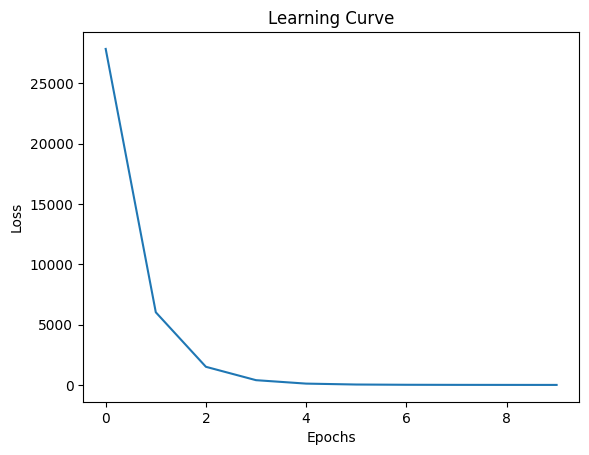

In [2299]:
plt.plot(list(range(10)), errors)
plt.xlabel('Epochs')
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.show()

In [2300]:
def predict(X, params):

  M = np.dot(X, params['W'])

  P = M + params['B']

  return P

In [2301]:
prediction = predict(X, params)

In [2302]:
prediction

array([[0.74168234],
       [3.09842338],
       [3.12522008],
       [5.76526487]])

In [2306]:
Y

array([[2],
       [5],
       [6],
       [3]])

In [2307]:
Y.shape

(4, 1)

In [2308]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])